<a href="https://colab.research.google.com/github/biswal-prem-5677/Coding-Journey/blob/main/languages/python/mini_projects/web_scraping/experiment_ecommerce_price_scraping_discount_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## E-commerce Product Price Scraper and Discount Visualizer

This notebook will demonstrate how to build a web scraper using BeautifulSoup to extract product prices from an e-commerce website and then visualize any discounts using Seaborn.

In [1]:
# Install necessary libraries
!pip install requests beautifulsoup4 pandas seaborn matplotlib

In [20]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re # Import the regular expression module

### Step 1: Define the Target URL and Fetch HTML Content

First, we need to specify the URL of the e-commerce page we want to scrape and then fetch its HTML content.

In [17]:
# Define the URL to scrape
# IMPORTANT: Replace this with the actual URL of the e-commerce page you want to scrape.
# Ensure you have permission to scrape the website.
URL = 'https://books.toscrape.com/'

# Send a GET request to the URL and parse HTML
try:
    response = requests.get(URL)
    response.raise_for_status()  # Raise an exception for HTTP errors (4xx or 5xx)
    html_content = response.text
    print(f"Successfully fetched content from {URL}")

    # Create a BeautifulSoup object immediately after fetching
    soup = BeautifulSoup(html_content, 'html.parser')
    print("HTML content successfully parsed with BeautifulSoup.")

except requests.exceptions.RequestException as e:
    print(f"Error fetching URL: {e}")
    html_content = None
    soup = None # Set soup to None in case of error
except Exception as e:
    print(f"An unexpected error occurred during parsing: {e}")
    soup = None

Successfully fetched content from https://books.toscrape.com/
HTML content successfully parsed with BeautifulSoup.


### Step 2: Parse HTML Content with BeautifulSoup

Now that we have the HTML content, we'll use BeautifulSoup to parse it and make it easier to navigate and extract data.

### Step 3: Extract Product Data

This is the most crucial part and will be highly dependent on the structure of the e-commerce website you are scraping. You will need to inspect the HTML of the product page (e.g., using your browser's developer tools) to find the unique CSS selectors or HTML tags/attributes that contain the product name, original price, and discounted price.

**Common elements to look for:**
*   Product name: Often within `<h1>`, `<h2>`, `<h3>`, `<a>` tags with specific classes.
*   Price: Often within `<span>`, `<p>`, `<b>` tags with classes like `price`, `current-price`, `product-price`.
*   Original/Old Price: Sometimes crossed out, with classes like `old-price`, `original-price`.
*   Discounted/Sale Price: With classes like `sale-price`, `discount-price`.

Once you identify these, you can use `soup.find()` or `soup.find_all()` to extract the data.

In [23]:
# Initialize lists to store product data
product_names = []
original_prices = []
discounted_prices = []

if soup:
    # --- USER CUSTOMIZATION REQUIRED HERE ---
    # Example: Find all product containers (e.g., div with a specific class)
    # This is a placeholder; you'll need to adapt it to the target website's HTML structure.
    # For instance, if each product is in a div with class 'product-item':
    # product_containers = soup.find_all('div', class_='product-item')
    product_containers = soup.find_all('article', class_='product_pod') # Updated for books.toscrape.com

    if not product_containers:
        print("Could not find any product containers. Please verify your selector.")

    for container in product_containers:
        # Example: Extract product name
        # name_element = container.find('h2', class_='product-name')
        # product_names.append(name_element.text.strip() if name_element else 'N/A')
        name_element = container.find('h3').find('a') # Updated for books.toscrape.com
        product_names.append(name_element['title'].strip() if name_element and 'title' in name_element.attrs else 'N/A')

        # Example: Extract price (books.toscrape.com only has one price, so we use it for both original and discounted)
        price_element = container.find('p', class_='price_color') # Updated for books.toscrape.com
        price = price_element.text.strip() if price_element else 'N/A'
        original_prices.append(price)
        discounted_prices.append(price) # Using the same price for discounted price as there's no separate discount

    print(f"Extracted {len(product_names)} products.")
else:
    print("Cannot extract data: HTML content was not parsed successfully.")

Extracted 20 products.


### Step 4: Clean Data and Calculate Discounts

The extracted prices are likely strings, possibly containing currency symbols or other non-numeric characters. We need to clean these strings and convert them into numerical (float) values. Then, we can calculate the discount percentage or absolute discount.

We will also handle cases where original or discounted prices might be missing.

In [24]:
def clean_price(price_str):
    if isinstance(price_str, str):
        # Use regex to find all digits and the decimal point
        # This is more robust than chained replace statements for various currency symbols
        match = re.search(r'\d+\.?\d*', price_str)
        if match:
            try:
                return float(match.group(0))
            except ValueError:
                return None # Return None if conversion fails even after regex extraction
    return None # Return None if input is not a string or no match found

cleaned_original_prices = [clean_price(p) for p in original_prices]
cleaned_discounted_prices = [clean_price(p) for p in discounted_prices]

discounts = []
for i in range(len(product_names)):
    original = cleaned_original_prices[i]
    discounted = cleaned_discounted_prices[i]

    if original is not None and discounted is not None and original > 0:
        discount_percent = ((original - discounted) / original) * 100
        discounts.append(round(discount_percent, 2))
    else:
        discounts.append(None) # No discount if prices are missing or invalid

print(f"Cleaned {len(cleaned_original_prices)} original prices and {len(cleaned_discounted_prices)} discounted prices.")
print(f"Calculated {len(discounts)} discounts.")

Cleaned 20 original prices and 20 discounted prices.
Calculated 20 discounts.


### Step 5: Create a Pandas DataFrame

To organize our data and prepare it for visualization, we'll store the extracted product information in a Pandas DataFrame.

In [25]:
product_data = pd.DataFrame({
    'Product Name': product_names,
    'Original Price': cleaned_original_prices,
    'Discounted Price': cleaned_discounted_prices,
    'Discount Percentage': discounts
})

# Display the first few rows of the DataFrame
print("Product Data DataFrame created successfully:")
print(product_data.head())

# Display some basic statistics
print("\nDataFrame Info:")
product_data.info()


Product Data DataFrame created successfully:
                            Product Name  Original Price  Discounted Price  \
0                   A Light in the Attic           51.77             51.77   
1                     Tipping the Velvet           53.74             53.74   
2                             Soumission           50.10             50.10   
3                          Sharp Objects           47.82             47.82   
4  Sapiens: A Brief History of Humankind           54.23             54.23   

   Discount Percentage  
0                  0.0  
1                  0.0  
2                  0.0  
3                  0.0  
4                  0.0  

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Product Name         20 non-null     object 
 1   Original Price       20 non-null     float64
 2   Discounted P

### Step 6: Visualize Discounts

Finally, we can use Seaborn and Matplotlib to visualize the discounts. This will help us understand the distribution of discounts across products.

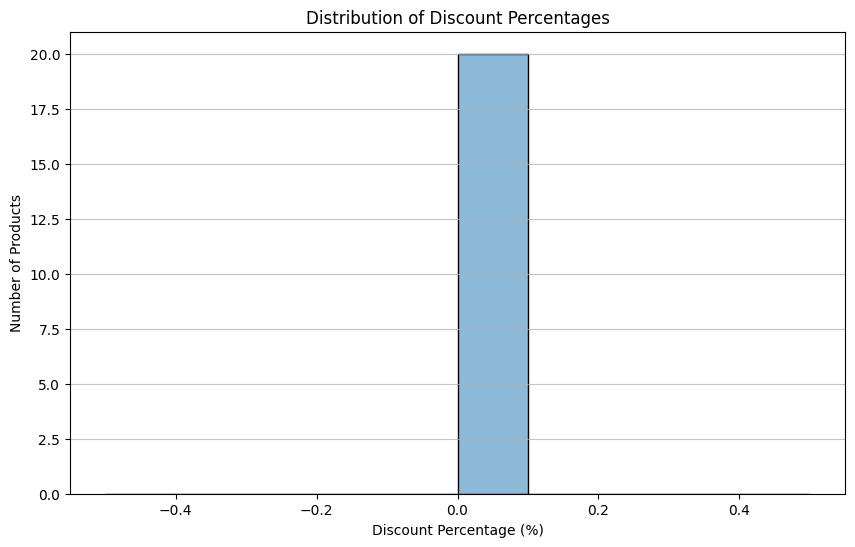

In [27]:
# Filter out products with no discount for visualization clarity
discounted_products = product_data.dropna(subset=['Discount Percentage']).copy()

if not discounted_products.empty:
    plt.figure(figsize=(10, 6))
    sns.histplot(discounted_products['Discount Percentage'], bins=10, kde=True)
    plt.title('Distribution of Discount Percentages')
    plt.xlabel('Discount Percentage (%)')
    plt.ylabel('Number of Products')
    plt.grid(axis='y', alpha=0.75)
    plt.show()
else:
    print("No discounted products found to visualize, or DataFrame is empty.")